In [1]:
from torch.utils.data import DataLoader
from miao import VolumeDataset, load_config

In [2]:
config = load_config("/groups/troidl/home/troidlj/miaio/examples/config.yaml")
dataset = VolumeDataset(config)

In [3]:
x = dataset[0]

print(x['meta'])
print(x['img'].shape)
print(x['bbox'])

{'volume': 'Jiefu Cerebellum FIB-SEM', 'coordinate': [4970, 1563, 4882], 'scale_levels': [0, 1, 2]}
torch.Size([1, 3, 128, 128, 32])
tensor([[[4818., 1499., 4954.],
         [4946., 1627., 4986.]],

        [[4754., 1434., 4938.],
         [5010., 1690., 5002.]],

        [[4624., 1304., 4904.],
         [5136., 1816., 5032.]]])


In [4]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(loader))

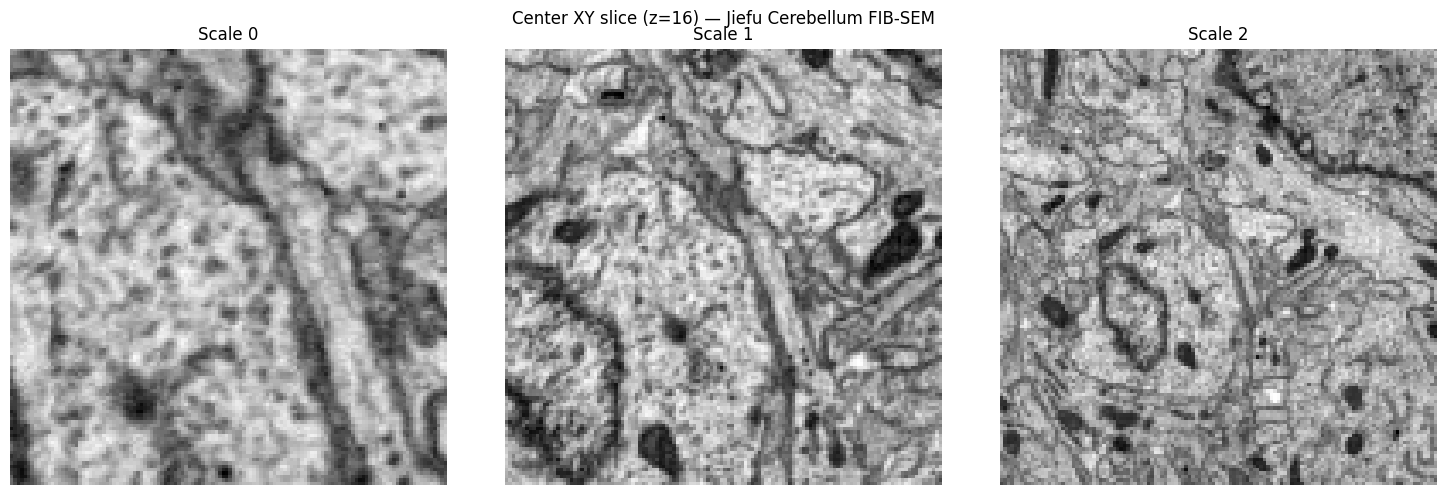

In [5]:
import matplotlib.pyplot as plt

sample = dataset[0]
img = sample["img"]  # (1, L, X, Y, Z)
num_levels = img.shape[1]
center_z = img.shape[4] // 2

fig, axes = plt.subplots(1, num_levels, figsize=(5 * num_levels, 5))
if num_levels == 1:
    axes = [axes]
for i in range(num_levels):
    axes[i].imshow(img[0, i, :, :, center_z].numpy().T, cmap="gray", origin="lower")
    axes[i].set_title(f"Scale {sample['meta']['scale_levels'][i]}")
    axes[i].axis("off")
plt.suptitle(f"Center XY slice (z={center_z}) — {sample['meta']['volume']}")
plt.tight_layout()
plt.show()